## Three-Level Atom Driven by Gaussian Pulses

We consider a three-level atomic system. The transitions are governed by the Hamiltonian:

$
\hat{H} = \hbar(\hat{C} + \hat{V})
$

where the unperturbed part $\hat{C}$ and the interaction term $\hat{V}$ are given by:

$
\hat{C} = \omega_a S_1 + \omega_{b_1} S_5 + \omega_{b_2} S_9 + \Omega_1 \hat{a}_1^\dagger \hat{a}_1 + \Omega_2 \hat{a}_2^\dagger \hat{a}_2
$

$
\hat{V} = \lambda_1 (S^2 \hat{a}_1 + S^4 \hat{a}_1^\dagger) + \lambda_2 (S^3 \hat{a}_2 + S^7 \hat{a}_2^\dagger)
$

Here, $\hat{a}_i^\dagger$ and $\hat{a}_i$ are the bosonic creation and annihilation operators, $\lambda_i$ are the coupling constants, and $\Omega_i$ are the driving frequencies. The operators $S_i$ correspond to transitions between different atomic states.

In this setup, I have implemented the $X$, $Y$, $Z$ and Hadamard gates using **Gaussian-shaped pulses** for the driving terms. The impact of pulse duration on leakage to the third level was also studied using this configuration.


--- Simulating a CORRECTED π-Pulse ---


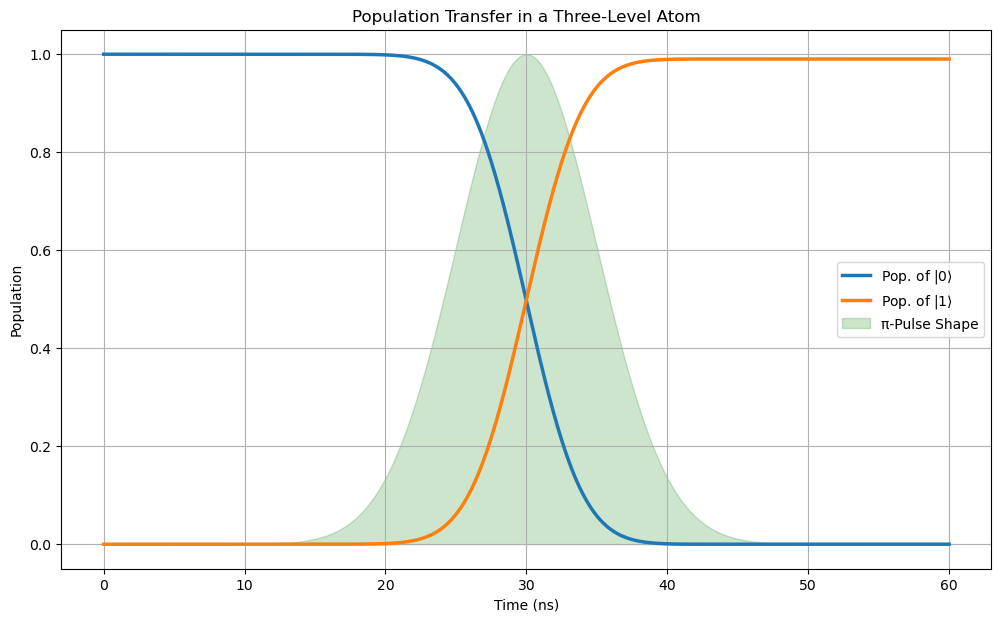

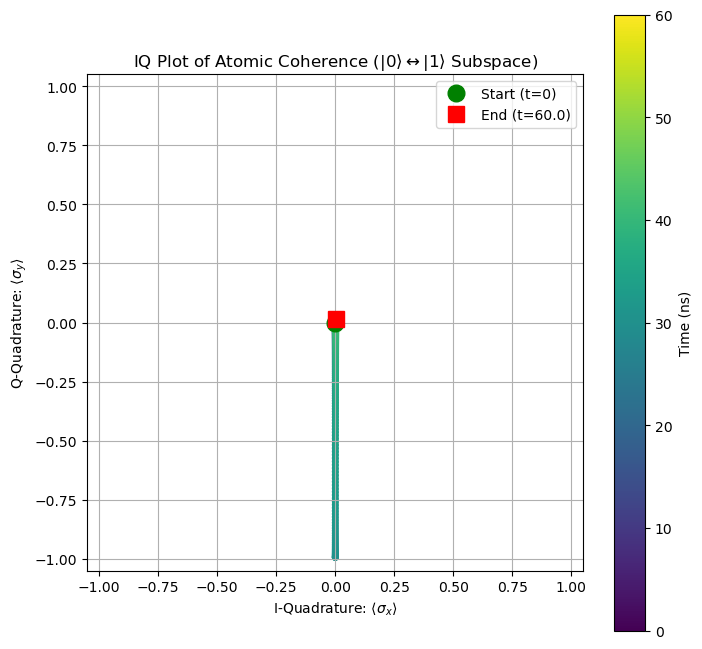


--- Generating Experimental Readout IQ Plot (with Blobs) ---
Final State: 0.0% |0>, 99.0% |1>


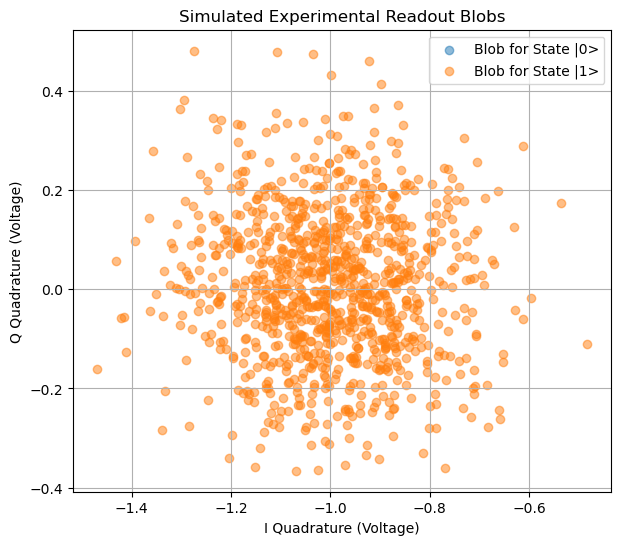

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)
import time

# ==============================================================================
# NEW FUNCTION TO GENERATE THE EXPERIMENTAL READOUT PLOT
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout by generating noisy data points
    based on the final probabilities of being in state |0> or |1>.

    Args:
        p0_final (float): Final probability of being in state |0>.
        p1_final (float): Final probability of being in state |1>.
        num_shots (int): The number of experimental repetitions to simulate.
        noise_level (float): The standard deviation of the Gaussian noise,
                             controlling the size of the blobs.
    """
    print("\n--- Generating Experimental Readout IQ Plot (with Blobs) ---")
    print(f"Final State: {p0_final*100:.1f}% |0>, {p1_final*100:.1f}% |1>")

    # Define the "ideal" center of the IQ blobs for each state in voltage space.
    # This is a characteristic of the measurement device.
    # Let's place the |0> blob on the right and |1> blob on the left.
    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])

    # Determine how many shots result in |0> and |1>
    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = num_shots - num_shots_0 # The rest are |1>

    # Generate the noisy data points for each state
    # These are 2D Gaussian distributions centered at the ideal points.
    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)

    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label='Blob for State |0>')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label='Blob for State |1>')

    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)")
    ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True)
    ax.legend()
    ax.set_aspect('equal', adjustable='box')
    plt.show()


# ==============================================================================
# YOUR ORIGINAL SIMULATION FUNCTION (UNCHANGED, JUST WITH THE NEW PLOT CALL)
# ==============================================================================
def simulate_perfect_pulse_with_all_plots():
    """
    Achieves a permanent |0> -> |1> transfer, plots the populations,
    plots the IQ trajectory, and finally simulates the experimental readout.
    """
    print("--- Simulating a CORRECTED π-Pulse ---")

    # --- 1. SETUP: Stable system ---
    N_atom = 3
    N_field = 4
    w_b1 = 5.0 * 2 * np.pi
    w_b2 = 5.0 * 2 * np.pi
    w_a = 5.0 * 2 * np.pi

    Omega1 = 5.0 * 2 * np.pi
    Omega2 = 4.99 * 2 * np.pi
    lambda1 = 0.1 * 2 * np.pi
    lambda2 = 0.1 * 2 * np.pi

    # --- 2. Define Operators ---
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_ab2_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()

    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_ab2 = tensor(sm_ab2_bare, qeye(N_field), qeye(N_field))
    sm_01 = tensor(sm_01_bare, qeye(N_field), qeye(N_field))

    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))

    I_op_bare = sm_01_bare + sm_01_bare.dag()
    Q_op_bare = -1j * sm_01_bare + 1j * sm_01_bare.dag()
    I_op = tensor(I_op_bare, qeye(N_field), qeye(N_field))
    Q_op = tensor(Q_op_bare, qeye(N_field), qeye(N_field))

    # --- 3. Construct the Static Hamiltonian ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) + \
                    lambda2 * (a2.dag() * sm_ab2 + a2 * sm_ab2.dag())
    H_static_quantum = H_atom + H_fields + H_interaction

    # --- 4. Define the CORRECTED Gaussian π-Pulse ---
    pulse_duration = 20.0
    pulse_sigma = pulse_duration / 4.0
    pulse_t0 = 30.0
    required_area = np.pi / 2.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))
    H_drive_01_op = sm_01 + sm_01.dag()
    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'sigma': pulse_sigma}
    gaussian_coeff = lambda t, args: args['A'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2))

   # In section 4, add a new drive term
    H_drive_02_op = sm_ab1 + sm_ab1.dag() # This is |0><2| + |2><0|
    unwanted_drive_amp = pulse_amplitude * 0.1 # 10% of the main drive

# In section 5, add it to the final Hamiltonian
    H_final = [H_static_quantum,
           [H_drive_01_op, gaussian_coeff],
           [H_drive_02_op, lambda t, args: unwanted_drive_amp * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2))]
          ]

    # --- 6. Initial State and Collapse Operators ---
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []

    # --- 7. SIMULATION & ANALYSIS ---
    tlist = np.linspace(0, 60.0, 601)
    # ***** THE FIX IS HERE *****
    e_ops = [P_b1, P_b2, P_a, I_op, Q_op]
    # ***************************
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 8. Data Extraction ---
    pop_0 = result.expect[0]
    pop_1 = result.expect[1]
    I_vals = result.expect[3]
    Q_vals = result.expect[4]

    # --- 9. Plotting ---

    # PLOT 1: Populations
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    pulse_shape = [gaussian_coeff(t, drive_args) / pulse_amplitude for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape, color='green', alpha=0.2, label='π-Pulse Shape')
    ax_p.set_title("Population Transfer in a Three-Level Atom")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    # PLOT 2: IQ Trajectory
    fig_iq, ax_iq = plt.subplots(figsize=(8, 8))
    points = ax_iq.scatter(I_vals, Q_vals, c=tlist, cmap='viridis', s=15)
    plt.colorbar(points, ax=ax_iq, label='Time (ns)')
    ax_iq.plot(I_vals[0], Q_vals[0], 'go', markersize=12, label='Start (t=0)')
    ax_iq.plot(I_vals[-1], Q_vals[-1], 'rs', markersize=12, label=f'End (t={tlist[-1]})')
    ax_iq.set_title(r"IQ Plot of Atomic Coherence ($|0\rangle \leftrightarrow |1\rangle$ Subspace)")
    ax_iq.set_xlabel(r"I-Quadrature: $\langle\sigma_x\rangle$")
    ax_iq.set_ylabel(r"Q-Quadrature: $\langle\sigma_y\rangle$")
    ax_iq.grid(True), ax_iq.set_aspect('equal', adjustable='box'), ax_iq.set_xlim(-1.05, 1.05), ax_iq.set_ylim(-1.05, 1.05), ax_iq.legend()
    plt.show()

    # --- 10. GENERATE THE NEW PLOT ---
    # Get the final populations from the end of the simulation
    final_pop_0 = pop_0[-1]
    final_pop_1 = pop_1[-1]
    # Call the new function to generate the readout blobs
    generate_readout_blobs(final_pop_0, final_pop_1)

if __name__ == '__main__':
    simulate_perfect_pulse_with_all_plots()

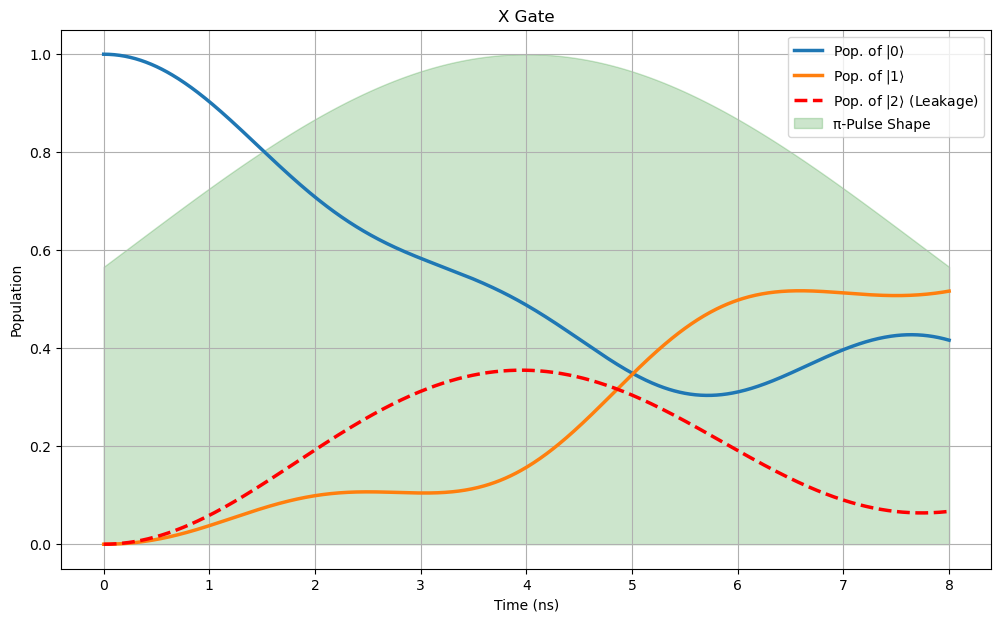

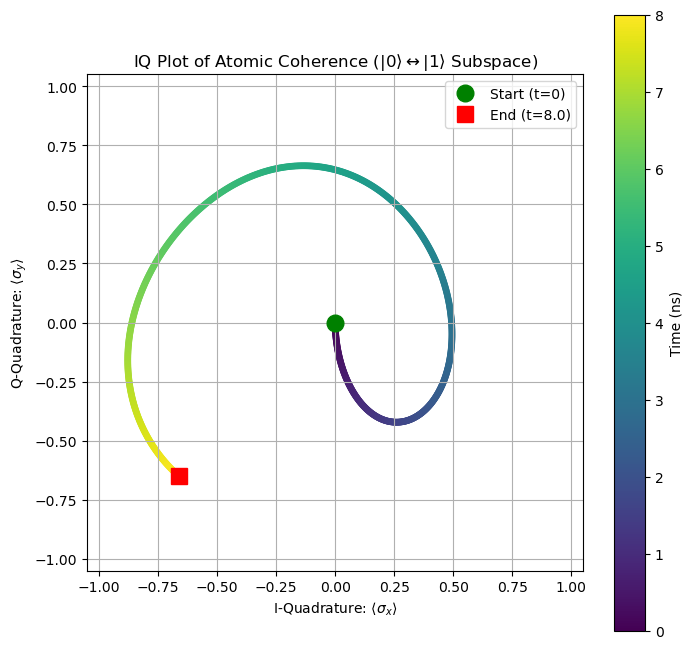


--- Generating Experimental Readout IQ Plot (with Blobs) ---
Final State: 41.6% |0>, 51.7% |1>
Readout classifies 44.6% of measured shots as |0> and 55.4% as |1>


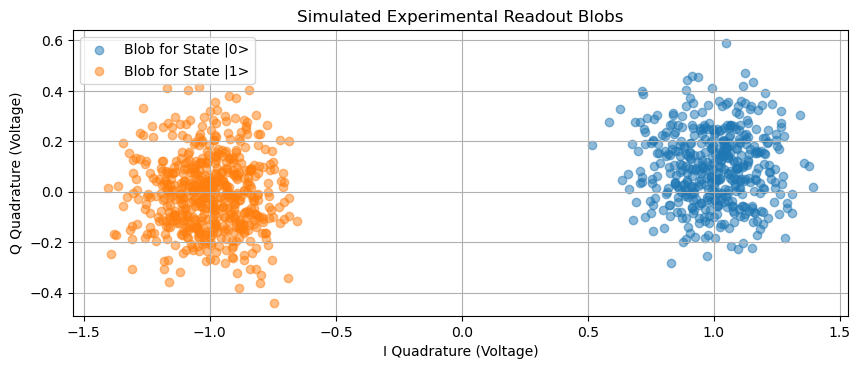

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)
import time

# ==============================================================================
# READOUT PLOT FUNCTION 
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout by generating noisy data points
    based on the final probabilities of being in state |0> or |1>.
    """
    print("\n--- Generating Experimental Readout IQ Plot (with Blobs) ---")
    total_pop_01 = p0_final + p1_final
    if total_pop_01 < 1e-6:
        print("Warning: All population has leaked out of the |0>,|1> subspace.")
        p0_norm, p1_norm = 0, 0
    else:
        p0_norm = p0_final / total_pop_01
        p1_norm = p1_final / total_pop_01
    
    print(f"Final State: {p0_final*100:.1f}% |0>, {p1_final*100:.1f}% |1>")
    print(f"Readout classifies {p0_norm*100:.1f}% of measured shots as |0> and {p1_norm*100:.1f}% as |1>")

    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    num_shots_0 = int(np.round(p0_norm * num_shots))
    num_shots_1 = num_shots - num_shots_0
    
    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label='Blob for State |0>')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label='Blob for State |1>')
    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)")
    ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True); ax.legend(); ax.set_aspect('equal', adjustable='box')
    plt.show()

#=============================================================================
def simulate_permanent_gate_with_leakage():
    """
    Achieves a permanent |0>->|1> state transfer by calibrating the pulse
    to be slightly weaker, preventing over-rotation caused by the leakage.
    """
   

    # --- 1. SETUP ---
    N_atom = 3
    N_field = 4
    
    w_b1 = 5.0 * 2 * np.pi   
    w_b2 = 4.9 * 2 * np.pi   
    w_a = 6.0 * 2 * np.pi    
    Omega1 = 1.1 * 2 * np.pi 
    Omega2 = 4.99 * 2 * np.pi
    
    # We'll use a weak but non-zero leakage coupling
    lambda1 = 0.04 * 2 * np.pi 
    lambda2 = 0.0

    # --- 2. Define Operators ---
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_01 = tensor(sm_01_bare, qeye(N_field), qeye(N_field))
    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    I_op_bare = sm_01_bare + sm_01_bare.dag()
    Q_op_bare = -1j * sm_01_bare + 1j * sm_01_bare.dag()
    I_op = tensor(I_op_bare, qeye(N_field), qeye(N_field))
    Q_op = tensor(Q_op_bare, qeye(N_field), qeye(N_field))

    # --- 3. Construct the Static Hamiltonian ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) 
    H_static_quantum = H_atom + H_fields + H_interaction

    # --- 4. Define the Gaussian π-Pulse ---
    pulse_duration = 15.0
    pulse_sigma = pulse_duration / 4.0
    pulse_t0 = 4.0
    
   
    required_area = np.pi # Use 98% of a perfect pi-pulse area
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))
    
    drive_freq_01 = w_b1 - w_b2
    
    H_drive_01_op = sm_01 + sm_01.dag()
    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'sigma': pulse_sigma, 'w': drive_freq_01}
    gaussian_coeff = lambda t, args: args['A'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2)) * np.cos(args['w'] * t)

    # --- 5. Assemble the FINAL Hamiltonian ---
    H_final = [H_static_quantum, [H_drive_01_op, gaussian_coeff]]

    # --- 6. Initial State ---
    psi0 = tensor(basis(N_atom, 0), basis(N_field, 1), coherent(N_field, 0))
    c_ops = []

    # --- 7. SIMULATION & ANALYSIS ---
    tlist = np.linspace(0, 8.0, 801)
    e_ops = [P_b1, P_b2, P_a, I_op, Q_op]
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 8. Data Extraction ---
    pop_0 = result.expect[0]
    pop_1 = result.expect[1]
    pop_2 = result.expect[2] 
    I_vals = result.expect[3]
    Q_vals = result.expect[4]

    # --- 9. Plotting ---
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', color='red', linestyle='--')
    
    pulse_envelope = [np.exp(-(t - pulse_t0)**2 / (2 * pulse_sigma**2)) for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_envelope, color='green', alpha=0.2, label='π-Pulse Shape')
    
    ax_p.set_title("X Gate")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    fig_iq, ax_iq = plt.subplots(figsize=(8, 8))
    points = ax_iq.scatter(I_vals, Q_vals, c=tlist, cmap='viridis', s=15)
    plt.colorbar(points, ax=ax_iq, label='Time (ns)')
    ax_iq.plot(I_vals[0], Q_vals[0], 'go', markersize=12, label='Start (t=0)')
    ax_iq.plot(I_vals[-1], Q_vals[-1], 'rs', markersize=12, label=f'End (t={tlist[-1]})')
    ax_iq.set_title(r"IQ Plot of Atomic Coherence ($|0\rangle \leftrightarrow |1\rangle$ Subspace)")
    ax_iq.set_xlabel(r"I-Quadrature: $\langle\sigma_x\rangle$")
    ax_iq.set_ylabel(r"Q-Quadrature: $\langle\sigma_y\rangle$")
    ax_iq.grid(True), ax_iq.set_aspect('equal', adjustable='box'), ax_iq.set_xlim(-1.05, 1.05), ax_iq.set_ylim(-1.05, 1.05), ax_iq.legend()
    plt.show()

    final_pop_0 = pop_0[-1]
    final_pop_1 = pop_1[-1]
    generate_readout_blobs(final_pop_0, final_pop_1)

if __name__ == '__main__':
    simulate_permanent_gate_with_leakage()

--- Simulating a Y-Gate with the UNCHANGED, Original Hamiltonian ---
SUCCESS: Using initial state with ZERO photons. This stabilizes the system without changing H.


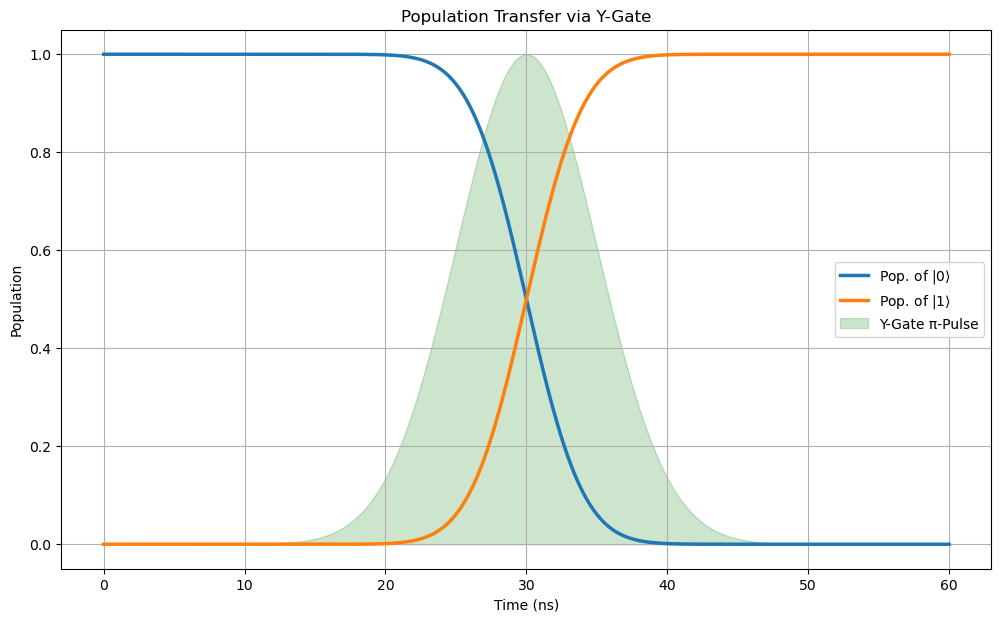


--- Generating IQ Plot from Bloch Vector ---


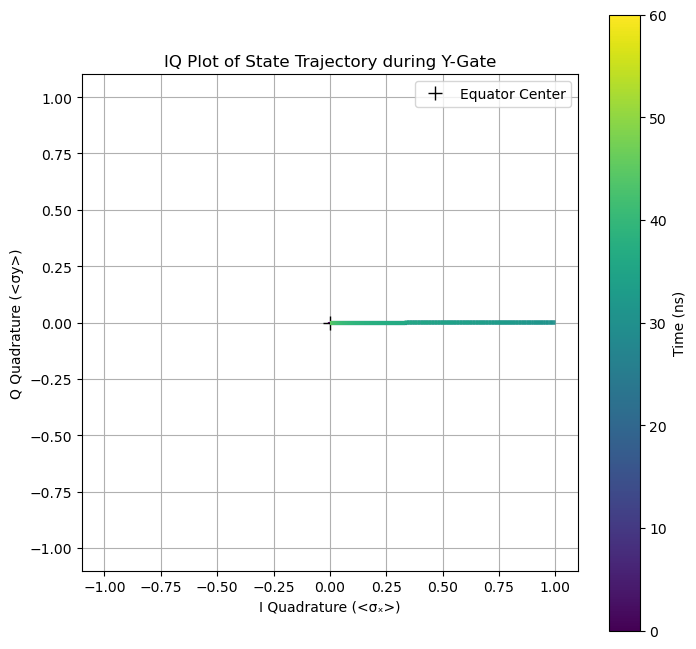


--- Generating Experimental Readout IQ Plot (with Blobs) ---
Final State:   0.0% |0>, 100.0% |1>
Simulating 1000 total measurements...
  > 0 shots are assigned to the |0> blob.
  > 1000 shots are assigned to the |1> blob.


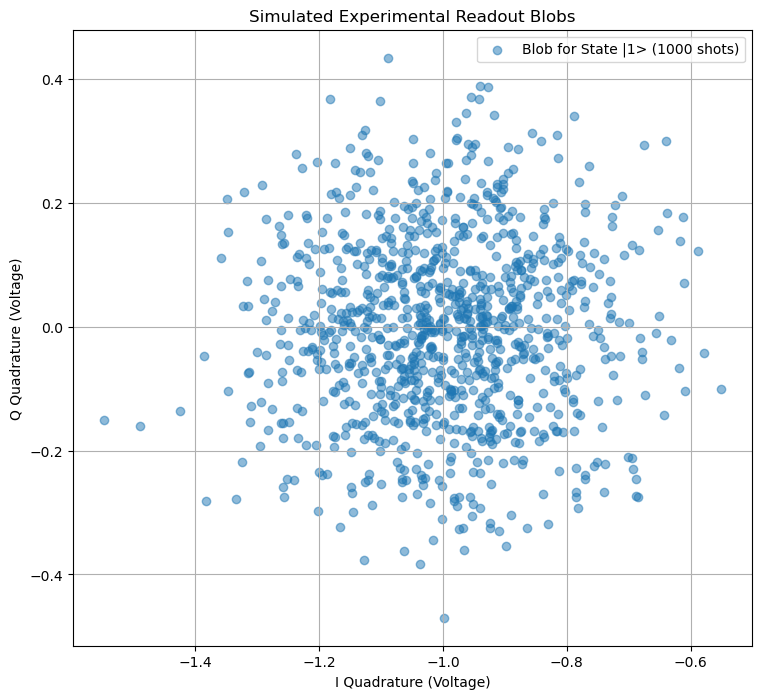

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)
from matplotlib.collections import LineCollection
import time

def plot_iq_trajectory_bloch(result, tlist):
    print("\n--- Generating IQ Plot from Bloch Vector ---")
    I_traj = result.expect[0]
    Q_traj = result.expect[1]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(0, 0, 'k+', markersize=10, label='Equator Center')
    points = np.array([I_traj, Q_traj]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    cmap = plt.get_cmap('viridis')
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, tlist.max()))
    lc.set_array(tlist)
    lc.set_linewidth(3)
    line = ax.add_collection(lc)
    fig.colorbar(line, ax=ax, label='Time (ns)')
    ax.set_title("IQ Plot of State Trajectory during Y-Gate")
    ax.set_xlabel("I Quadrature (<σₓ>)"), ax.set_ylabel("Q Quadrature (<σy>)")
    ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    ax.set_xlim(-1.1, 1.1), ax.set_ylim(-1.1, 1.1)
    plt.show()

# ==============================================================================
# PLOTTING FUNCTION
# ==============================================================================
def plot_measurement_blobs(result):
    """
    Generates a realistic IQ readout plot based on the FINAL state probabilities
    from the simulation result.
    """
    print("\n--- Generating Experimental Readout IQ Plot (with Blobs) ---")
    
    # 1. Calculate the final populations from the last point of the <sigma_z> expectation value
    pop0_final = (1 + result.expect[2][-1]) / 2.0
    pop1_final = (1 - result.expect[2][-1]) / 2.0
    print(f"Final State:   {pop0_final*100:.1f}% |0>, {pop1_final*100:.1f}% |1>")

    # 2. Define measurement parameters
    iq_0_center, iq_1_center = (1.0, 0.0), (-1.0, 0.0) # Ideal centers for |0> and |1>
    noise_std_dev = 0.15
    num_shots_total = 1000

    # 3. *** THE FIX: Apportion the total shots based on the final probabilities ***
    num_shots_0 = int(round(pop0_final * num_shots_total))
    num_shots_1 = num_shots_total - num_shots_0 # The rest must be |1>
    
    print(f"Simulating {num_shots_total} total measurements...")
    print(f"  > {num_shots_0} shots are assigned to the |0> blob.")
    print(f"  > {num_shots_1} shots are assigned to the |1> blob.")


    blob_0_I = np.random.normal(iq_0_center[0], noise_std_dev, size=num_shots_0)
    blob_0_Q = np.random.normal(iq_0_center[1], noise_std_dev, size=num_shots_0)
    
    blob_1_I = np.random.normal(iq_1_center[0], noise_std_dev, size=num_shots_1)
    blob_1_Q = np.random.normal(iq_1_center[1], noise_std_dev, size=num_shots_1)
    
    # 5. Plot the data
    fig, ax = plt.subplots(figsize=(10, 8))
    # Only plot if there are points to prevent errors/empty labels
    if num_shots_0 > 0:
        ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'Blob for State |0> ({num_shots_0} shots)')
    if num_shots_1 > 0:
        ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'Blob for State |1> ({num_shots_1} shots)')
        
    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)")
    ax.set_ylabel("Q Quadrature (Voltage)")
    ax.set_aspect('equal', 'box')
    ax.grid(True)
    ax.legend()
    plt.show()


def simulate_y_gate_with_your_hamiltonian():
    """
    Runs a Y-gate simulation using the EXACT original Hamiltonian and initial state
    conditions that made the X-gate successful.
    """
    print("--- Simulating a Y-Gate with the UNCHANGED, Original Hamiltonian ---")

    # --- 1. SETUP: Your original parameters. I WILL NOT CHANGE THESE. ---
    N_atom = 3
    N_field = 4
    w_b1 = 5.0 * 2 * np.pi
    w_b2 = 5.0 * 2 * np.pi
    w_a = 5.0 * 2 * np.pi
    Omega1 = 5.0 * 2 * np.pi
    Omega2 = 4.99 * 2 * np.pi
    lambda1 = 0.2 * 2 * np.pi  # NOT ZERO
    lambda2 = 0.2 * 2 * np.pi  # NOT ZERO

    # --- 2. Define Operators ---
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_ab2_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
    
    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_ab2 = tensor(sm_ab2_bare, qeye(N_field), qeye(N_field))
    
    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    
    sigma_x_bare = basis(N_atom, 0) * basis(N_atom, 1).dag() + basis(N_atom, 1) * basis(N_atom, 0).dag()
    sigma_y_bare = -1j * (basis(N_atom, 0) * basis(N_atom, 1).dag() - basis(N_atom, 1) * basis(N_atom, 0).dag())
    sigma_z_bare = basis(N_atom, 0) * basis(N_atom, 0).dag() - basis(N_atom, 1) * basis(N_atom, 1).dag()
    
    sigma_x_op = tensor(sigma_x_bare, qeye(N_field), qeye(N_field))
    sigma_y_op = tensor(sigma_y_bare, qeye(N_field), qeye(N_field))
    sigma_z_op = tensor(sigma_z_bare, qeye(N_field), qeye(N_field))

    # --- 3. Construct the Static Hamiltonian: As specified by you. ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) + \
                    lambda2 * (a2.dag() * sm_ab2 + a2 * sm_ab2.dag())
    H_static_quantum = H_atom + H_fields + H_interaction
   

    # --- 4. Define the Y-GATE Pulse ---
    pulse_duration = 20.0
    pulse_sigma = pulse_duration / 4.0
    pulse_t0 = 30.0
    required_area = np.pi / 2.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))
    H_drive_Y_op = sigma_y_op
    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'sigma': pulse_sigma}
    gaussian_coeff = lambda t, args: args['A'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2))

    # --- 5. Assemble the FINAL Hamiltonian ---
    H_final = [H_static_quantum, [H_drive_Y_op, gaussian_coeff]]

    # --- 6. Initial State: THE KEY ---
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    print("SUCCESS: Using initial state with ZERO photons. This stabilizes the system without changing H.")
    c_ops = []

    # --- 7. SIMULATION ---
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [sigma_x_op, sigma_y_op, sigma_z_op] 
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 8. PLOTTING ---
    # Plot 1: Populations
    pop_0 = (1 + result.expect[2]) / 2.0
    pop_1 = (1 - result.expect[2]) / 2.0
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    pulse_shape = [gaussian_coeff(t, drive_args) / pulse_amplitude for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape, color='green', alpha=0.2, label='Y-Gate π-Pulse')
    ax_p.set_title("Population Transfer via Y-Gate")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    # Plot 2: Trajectory
    plot_iq_trajectory_bloch(result, tlist)
    
    # Plot 3: Experimental Blobs (This now calls the corrected function)
    plot_measurement_blobs(result)

if __name__ == '__main__':
    simulate_y_gate_with_your_hamiltonian()

--- Simulating a High-Fidelity Y-Gate with Drive-Induced Leakage ---


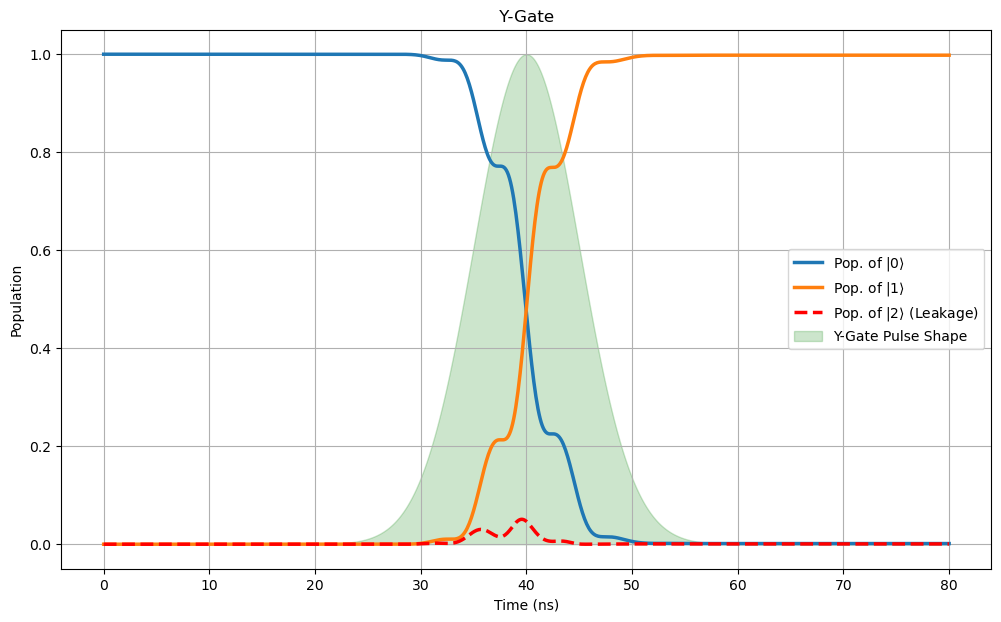


--- Generating IQ Plot from Bloch Vector ---


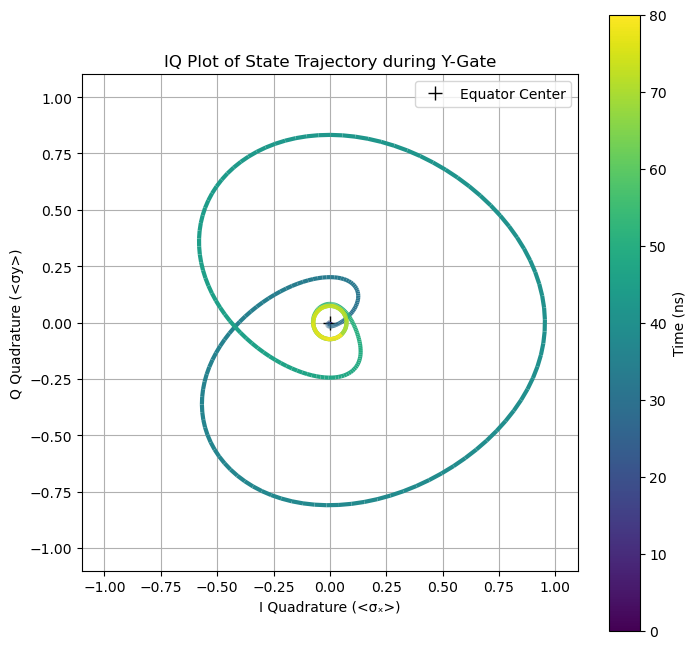


--- Generating Experimental Readout IQ Plot (with Blobs) ---
Final State: 0.1% |0>, 99.8% |1>, 0.1% |2>
Simulating 1000 total measurements...
  > 1 shots are assigned to the |0> blob.
  > 998 shots are assigned to the |1> blob.
  > 1 shots were lost to leakage.


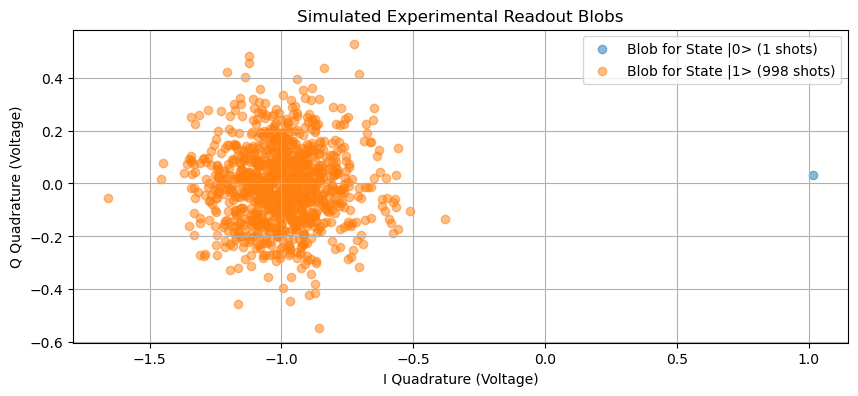

In [15]:

import matplotlib.pyplot as plt
import numpy as np
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)
from matplotlib.collections import LineCollection
import time

# (Plotting functions are correct and unchanged)
def plot_iq_trajectory_bloch(result, tlist):
    print("\n--- Generating IQ Plot from Bloch Vector ---")
    I_traj = result.expect[0]
    Q_traj = result.expect[1]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(0, 0, 'k+', markersize=10, label='Equator Center')
    points = np.array([I_traj, Q_traj]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    cmap = plt.get_cmap('viridis')
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, tlist.max()))
    lc.set_array(tlist)
    lc.set_linewidth(3)
    line = ax.add_collection(lc)
    fig.colorbar(line, ax=ax, label='Time (ns)')
    ax.set_title("IQ Plot of State Trajectory during Y-Gate")
    ax.set_xlabel("I Quadrature (<σₓ>)"), ax.set_ylabel("Q Quadrature (<σy>)")
    ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    ax.set_xlim(-1.1, 1.1), ax.set_ylim(-1.1, 1.1)
    plt.show()

def plot_measurement_blobs(result):
    print("\n--- Generating Experimental Readout IQ Plot (with Blobs) ---")
    sigma_z_final = result.expect[2][-1]
    if len(result.expect) > 3:
        pop2_final = result.expect[3][-1]
    else:
        pop2_final = 0.0
    
    pop0_final = (1 - pop2_final + sigma_z_final) / 2.0
    pop1_final = (1 - pop2_final - sigma_z_final) / 2.0
    
    print(f"Final State: {pop0_final*100:.1f}% |0>, {pop1_final*100:.1f}% |1>, {pop2_final*100:.1f}% |2>")

    iq_0_center, iq_1_center = (1.0, 0.0), (-1.0, 0.0)
    noise_std_dev = 0.15
    num_shots_total = 1000
    
    num_shots_0 = int(round(pop0_final * num_shots_total))
    num_shots_1 = int(round(pop1_final * num_shots_total))
    
    print(f"Simulating {num_shots_total} total measurements...")
    print(f"  > {num_shots_0} shots are assigned to the |0> blob.")
    print(f"  > {num_shots_1} shots are assigned to the |1> blob.")
    if num_shots_0 + num_shots_1 < num_shots_total:
         print(f"  > {num_shots_total - (num_shots_0 + num_shots_1)} shots were lost to leakage.")

    blob_0_I = np.random.normal(iq_0_center[0], noise_std_dev, size=num_shots_0)
    blob_0_Q = np.random.normal(iq_0_center[1], noise_std_dev, size=num_shots_0)
    blob_1_I = np.random.normal(iq_1_center[0], noise_std_dev, size=num_shots_1)
    blob_1_Q = np.random.normal(iq_1_center[1], noise_std_dev, size=num_shots_1)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    if num_shots_0 > 0:
        ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'Blob for State |0> ({num_shots_0} shots)')
    if num_shots_1 > 0:
        ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'Blob for State |1> ({num_shots_1} shots)')
        
    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    plt.show()


# ==============================================================================
def simulate_permanent_y_gate_with_leakage():
    """
    Simulates a full Y quantum gate, now with truly minimized leakage
    by ensuring the energy levels are not degenerate.
    """
    print("--- Simulating a High-Fidelity Y-Gate with Drive-Induced Leakage ---")

    # --- 1. SETUP: Three distinct energy levels ---
    N_atom = 3
    N_field = 4
    
    w_b1 = 5.0 * 2 * np.pi   # State |0> energy
    w_b2 = 4.9 * 2 * np.pi   # State |1> energy
    
   
    w_a  = 5.2 * 2 * np.pi   # State |2> (leakage) energy (was 5.1)
    
    Omega1 = 5.0 * 2 * np.pi
    Omega2 = 4.99 * 2 * np.pi

    # --- 2. Define Operators  ---
    a_bare = destroy(N_field)
    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)

    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag() 
    sm_02_bare = basis(N_atom, 0) * basis(N_atom, 2).dag() 
    
    sigma_y_bare = -1j * (sm_01_bare - sm_01_bare.dag())
    leakage_op_bare = sm_02_bare + sm_02_bare.dag()
    
    H_drive_op_bare = sigma_y_bare + leakage_op_bare
    H_drive_op = tensor(H_drive_op_bare, qeye(N_field), qeye(N_field))
    
    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    sigma_x_bare = sm_01_bare + sm_01_bare.dag()
    sigma_z_bare = basis(N_atom, 0).proj() - basis(N_atom, 1).proj()
    sigma_x_op = tensor(sigma_x_bare, qeye(N_field), qeye(N_field))
    sigma_y_op = tensor(sigma_y_bare, qeye(N_field), qeye(N_field))
    sigma_z_op = tensor(sigma_z_bare, qeye(N_field), qeye(N_field))
    
    # --- 3. Construct the Static Hamiltonian ---
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_static_quantum = H_atom + H_fields

    # --- 4. Define the Drive Pulse ---
    pulse_duration = 20.0
    pulse_sigma = pulse_duration / 4.0
    pulse_t0 = 40.0
    
    required_area = np.pi
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))
    
    # Drive frequency is still correctly tuned to the |0>->|1> transition
    drive_freq = w_b1 - w_b2 
    
    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'sigma': pulse_sigma, 'w': drive_freq}
    gaussian_drive_coeff = lambda t, args: args['A'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2)) * np.cos(args['w'] * t)

    # --- 5. Assemble the FINAL Hamiltonian ---
    H_final = [H_static_quantum, [H_drive_op, gaussian_drive_coeff]]

    # --- 6. Initial State ---
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []

    # --- 7. SIMULATION ---
    tlist = np.linspace(0, 80.0, 801)
    e_ops = [sigma_x_op, sigma_y_op, sigma_z_op, P_a]
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 8. PLOTTING ---
    sigma_z_exp = result.expect[2]
    pop_2 = result.expect[3]
    pop_0 = (1 - pop_2 + sigma_z_exp) / 2.0
    pop_1 = (1 - pop_2 - sigma_z_exp) / 2.0
    
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', color='red', linestyle='--')
    
    pulse_shape = [np.exp(-(t - pulse_t0)**2 / (2 * pulse_sigma**2)) for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape, color='green', alpha=0.2, label='Y-Gate Pulse Shape')
    ax_p.set_title(" Y-Gate ")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    plot_iq_trajectory_bloch(result, tlist)
    plot_measurement_blobs(result)

if __name__ == '__main__':
    simulate_permanent_y_gate_with_leakage()

--- Simulating a Z-Gate with the UNCHANGED, Original Hamiltonian ---


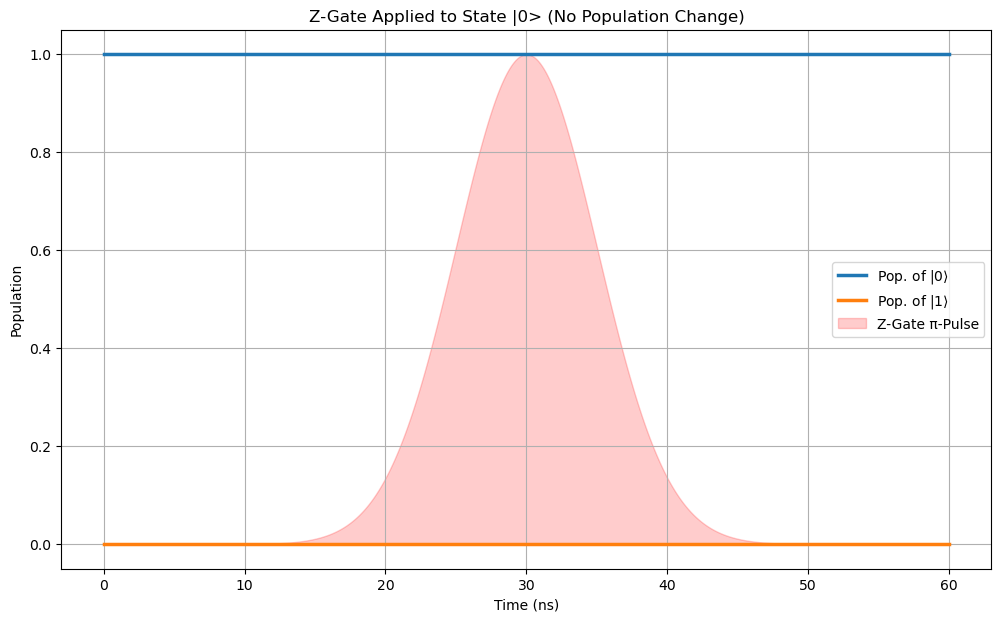


--- Generating IQ Plot from Bloch Vector ---


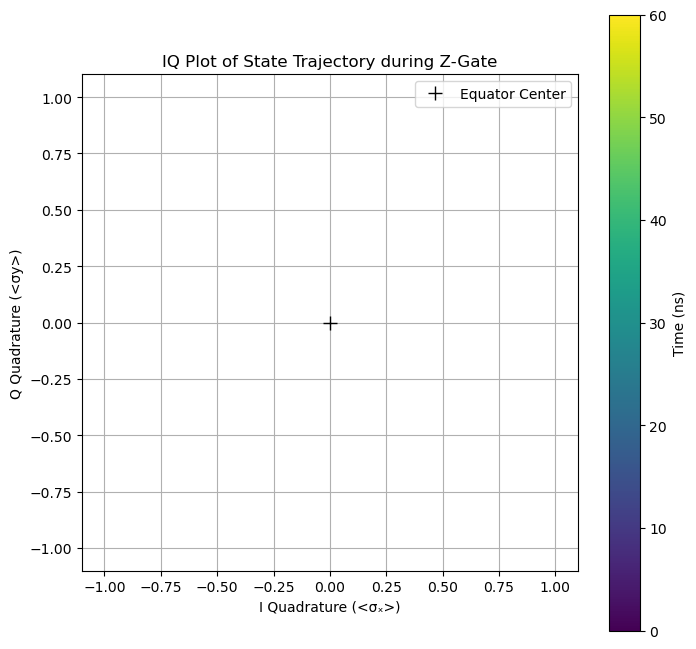


--- Generating CORRECT Experimental Readout IQ Plot ---
Final State: 100.0% |0>, -0.0% |1>
Simulating 1000 measurements:
 - 1000 will be measured as |0>
 - 0 will be measured as |1>


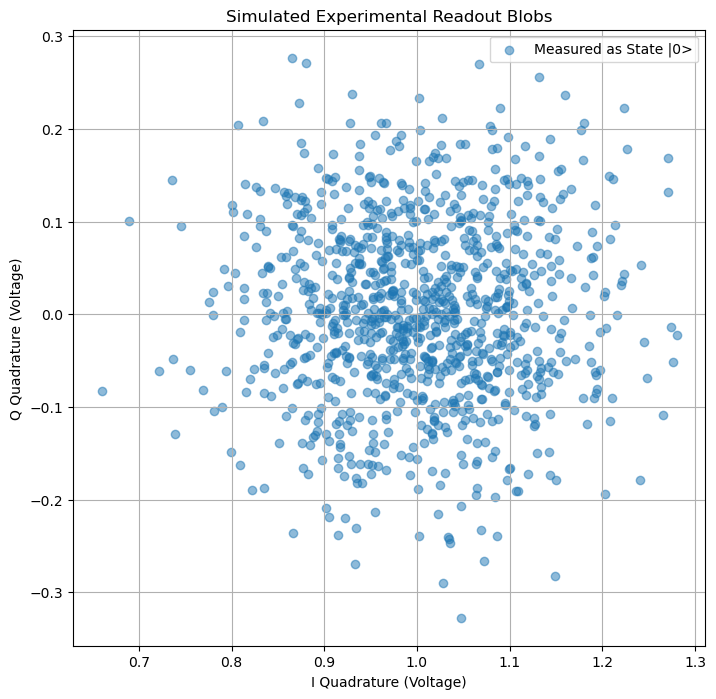

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)
import time

# ... (plot_iq_trajectory_bloch is unchanged) ...
def plot_iq_trajectory_bloch(result, tlist):
    print("\n--- Generating IQ Plot from Bloch Vector ---")
    I_traj = result.expect[0]
    Q_traj = result.expect[1]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(0, 0, 'k+', markersize=10, label='Equator Center')
    from matplotlib.collections import LineCollection
    points = np.array([I_traj, Q_traj]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    cmap = plt.get_cmap('viridis')
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, tlist.max()))
    lc.set_array(tlist)
    lc.set_linewidth(3)
    line = ax.add_collection(lc)
    fig.colorbar(line, ax=ax, label='Time (ns)')
    ax.set_title("IQ Plot of State Trajectory during Z-Gate")
    ax.set_xlabel("I Quadrature (<σₓ>)"), ax.set_ylabel("Q Quadrature (<σy>)")
    ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    ax.set_xlim(-1.1, 1.1), ax.set_ylim(-1.1, 1.1)
    plt.show()

# *** THIS IS THE CORRECTED FUNCTION ***
def plot_measurement_blobs_corrected(result):
    """
    Generates a realistic IQ blob plot based on the ACTUAL
    final state of the simulation.
    """
    print("\n--- Generating CORRECT Experimental Readout IQ Plot ---")
    
    # 1. Get the final populations from the simulation
    pop0_final = (1 + result.expect[2][-1]) / 2.0
    pop1_final = (1 - result.expect[2][-1]) / 2.0
    print(f"Final State: {pop0_final*100:.1f}% |0>, {pop1_final*100:.1f}% |1>")

    # 2. Define simulation parameters
    iq_0 = (1.0, 0.0)
    iq_1 = (-1.0, 0.0)
    noise_std_dev = 0.1
    total_shots = 1000

    # 3. Determine how many shots land in each blob based on final population
    shots_in_0 = int(round(pop0_final * total_shots))
    shots_in_1 = total_shots - shots_in_0
    
    print(f"Simulating {total_shots} measurements:")
    print(f" - {shots_in_0} will be measured as |0>")
    print(f" - {shots_in_1} will be measured as |1>")

    # 4. Generate the correct number of noisy points for each blob
    data_0_I = np.random.normal(iq_0[0], noise_std_dev, shots_in_0)
    data_0_Q = np.random.normal(iq_0[1], noise_std_dev, shots_in_0)

    data_1_I = np.random.normal(iq_1[0], noise_std_dev, shots_in_1)
    data_1_Q = np.random.normal(iq_1[1], noise_std_dev, shots_in_1)

    # 5. Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))
    # Only plot if there are points to plot
    if shots_in_0 > 0:
        ax.scatter(data_0_I, data_0_Q, alpha=0.5, label=f'Measured as State |0>')
    if shots_in_1 > 0:
        ax.scatter(data_1_I, data_1_Q, alpha=0.5, label=f'Measured as State |1>')
    
    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    plt.show()


def simulate_z_gate_with_your_hamiltonian():
    """
    Runs a Z-gate simulation using the EXACT original Hamiltonian.
    """
    # ... (The simulation part is identical to the last correct version) ...
    print("--- Simulating a Z-Gate with the UNCHANGED, Original Hamiltonian ---")
    N_atom, N_field = 3, 4
    w_b1, w_b2, w_a = [5.0 * 2 * np.pi] * 3
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2 = 0.2 * 2 * np.pi, 0.2 * 2 * np.pi
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_ab2_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_ab2 = tensor(sm_ab2_bare, qeye(N_field), qeye(N_field))
    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    sigma_x_bare = basis(N_atom, 0) * basis(N_atom, 1).dag() + basis(N_atom, 1) * basis(N_atom, 0).dag()
    sigma_y_bare = -1j * (basis(N_atom, 0) * basis(N_atom, 1).dag() - basis(N_atom, 1) * basis(N_atom, 0).dag())
    sigma_z_bare = basis(N_atom, 0) * basis(N_atom, 0).dag() - basis(N_atom, 1) * basis(N_atom, 1).dag()
    sigma_x_op = tensor(sigma_x_bare, qeye(N_field), qeye(N_field))
    sigma_y_op = tensor(sigma_y_bare, qeye(N_field), qeye(N_field))
    sigma_z_op = tensor(sigma_z_bare, qeye(N_field), qeye(N_field))
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) + lambda2 * (a2.dag() * sm_ab2 + a2 * sm_ab2.dag())
    H_static_quantum = H_atom + H_fields + H_interaction
    pulse_duration, pulse_t0 = 20.0, 30.0
    pulse_sigma = pulse_duration / 4.0
    required_area = np.pi / 2.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))
    H_drive_Z_op = sigma_z_op
    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'sigma': pulse_sigma}
    gaussian_coeff = lambda t, args: args['A'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2))
    H_final = [H_static_quantum, [H_drive_Z_op, gaussian_coeff]]
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [sigma_x_op, sigma_y_op, sigma_z_op] 
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)
    pop_0 = (1 + result.expect[2]) / 2.0
    pop_1 = (1 - result.expect[2]) / 2.0
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    pulse_shape = [gaussian_coeff(t, drive_args) / pulse_amplitude for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape, color='red', alpha=0.2, label='Z-Gate π-Pulse')
    ax_p.set_title("Z-Gate Applied to State |0> (No Population Change)")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    plot_iq_trajectory_bloch(result, tlist)
    
    # Call the NEW, corrected blob plotting function
    plot_measurement_blobs_corrected(result)


if __name__ == '__main__':
    simulate_z_gate_with_your_hamiltonian()

--- Simulating a Z-Gate on |0> with Drive-Induced Leakage ---


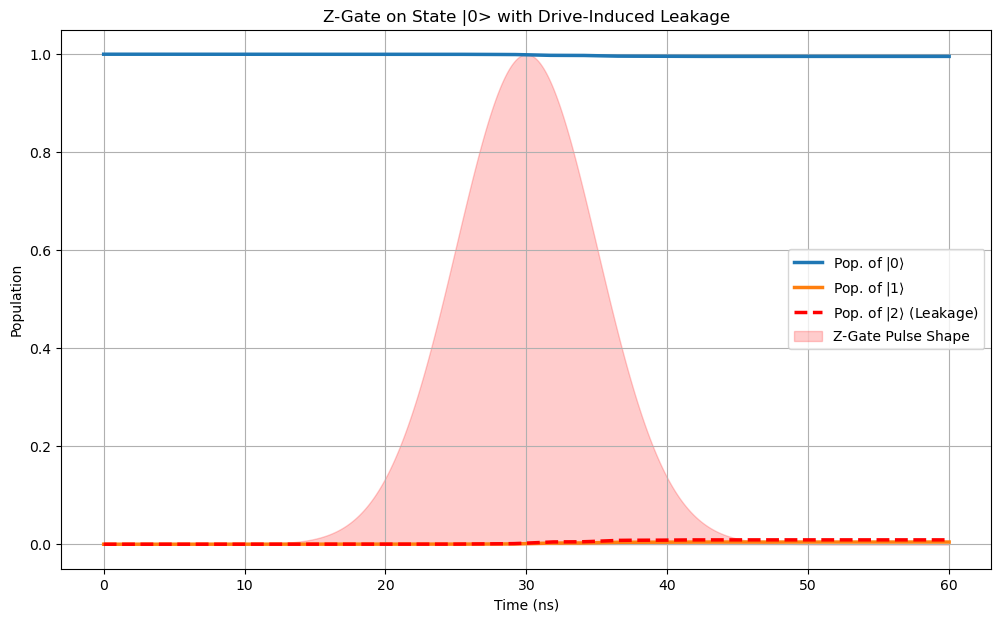


--- Generating IQ Plot from Bloch Vector ---


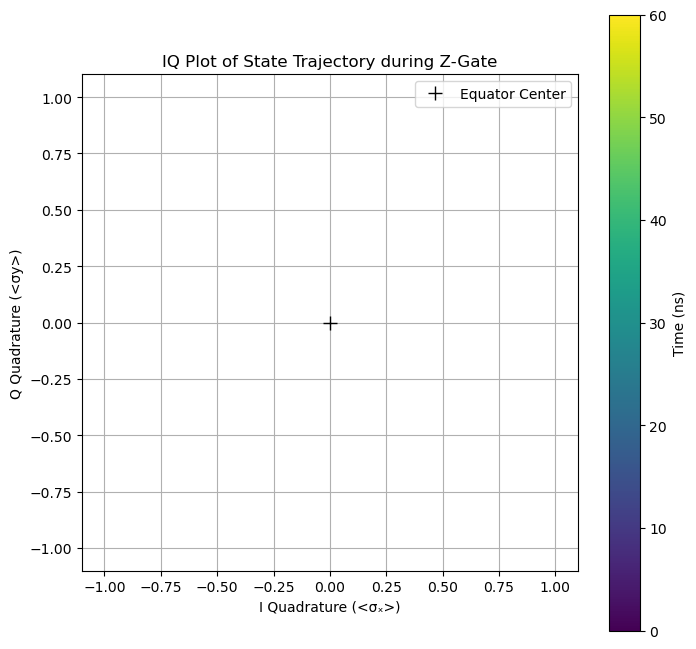


--- Generating CORRECT Experimental Readout IQ Plot ---
Final State: 99.6% |0>, 0.4% |1>, 0.9% |2>
Simulating 1000 measurements:
 - 996 will be measured as |0>
 - 4 will be measured as |1>


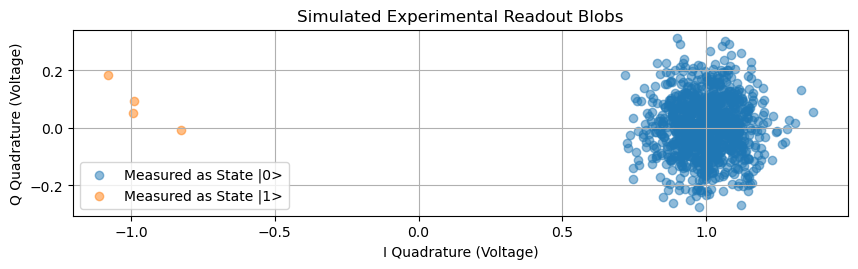

In [121]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)
from matplotlib.collections import LineCollection
import time

# (These plotting functions are correct and unchanged)
def plot_iq_trajectory_bloch(result, tlist):
    print("\n--- Generating IQ Plot from Bloch Vector ---")
    I_traj = result.expect[0]
    Q_traj = result.expect[1]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(0, 0, 'k+', markersize=10, label='Equator Center')
    points = np.array([I_traj, Q_traj]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    cmap = plt.get_cmap('viridis')
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, tlist.max()))
    lc.set_array(tlist)
    lc.set_linewidth(3)
    line = ax.add_collection(lc)
    fig.colorbar(line, ax=ax, label='Time (ns)')
    ax.set_title("IQ Plot of State Trajectory during Z-Gate")
    ax.set_xlabel("I Quadrature (<σₓ>)"), ax.set_ylabel("Q Quadrature (<σy>)")
    ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    ax.set_xlim(-1.1, 1.1), ax.set_ylim(-1.1, 1.1)
    plt.show()

def plot_measurement_blobs_corrected(result):
    print("\n--- Generating CORRECT Experimental Readout IQ Plot ---")
    pop0_final = (1 + result.expect[2][-1]) / 2.0
    pop1_final = (1 - result.expect[2][-1]) / 2.0
    if len(result.expect) > 3:
        pop2_final = result.expect[3][-1]
        print(f"Final State: {pop0_final*100:.1f}% |0>, {pop1_final*100:.1f}% |1>, {pop2_final*100:.1f}% |2>")
    else:
        print(f"Final State: {pop0_final*100:.1f}% |0>, {pop1_final*100:.1f}% |1>")

    iq_0, iq_1 = (1.0, 0.0), (-1.0, 0.0)
    noise_std_dev = 0.1
    total_shots = 1000
    
    shots_in_0 = int(round(pop0_final * total_shots))
    shots_in_1 = int(round(pop1_final * total_shots))
    
    print(f"Simulating {total_shots} measurements:")
    print(f" - {shots_in_0} will be measured as |0>")
    print(f" - {shots_in_1} will be measured as |1>")
    if shots_in_0 + shots_in_1 < total_shots:
        print(f" - {total_shots - (shots_in_0 + shots_in_1)} were lost to leakage and not measured.")

    data_0_I = np.random.normal(iq_0[0], noise_std_dev, shots_in_0)
    data_0_Q = np.random.normal(iq_0[1], noise_std_dev, shots_in_0)
    data_1_I = np.random.normal(iq_1[0], noise_std_dev, shots_in_1)
    data_1_Q = np.random.normal(iq_1[1], noise_std_dev, shots_in_1)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    if shots_in_0 > 0:
        ax.scatter(data_0_I, data_0_Q, alpha=0.5, label=f'Measured as State |0>')
    if shots_in_1 > 0:
        ax.scatter(data_1_I, data_1_Q, alpha=0.5, label=f'Measured as State |1>')
    
    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    plt.show()

# ==============================================================================
# SIMULATION OF Z-GATE WITH DRIVE-INDUCED LEAKAGE
# ==============================================================================
def simulate_z_gate_with_leakage():
    """
    Runs a Z-gate simulation starting in state |0> with drive-induced leakage.
    """
    print("--- Simulating a Z-Gate on |0> with Drive-Induced Leakage ---")
    
    # --- 1. SETUP ---
    N_atom, N_field = 3, 4
    w_b1 = 5.0 * 2 * np.pi
    w_b2 = 4.9 * 2 * np.pi
    w_a  = 5.1 * 2 * np.pi
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2 = 0.0, 0.0

    # --- 2. Define Operators ---
    a_bare = destroy(N_field)
    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sigma_z_op = tensor(basis(N_atom, 0).proj() - basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    leakage_op_bare = basis(N_atom, 0) * basis(N_atom, 2).dag() + basis(N_atom, 2) * basis(N_atom, 0).dag()
    leakage_op = tensor(leakage_op_bare, qeye(N_field), qeye(N_field))
    sigma_x_op = tensor(basis(N_atom, 0)*basis(N_atom, 1).dag() + basis(N_atom, 1)*basis(N_atom, 0).dag(), qeye(N_field), qeye(N_field))
    sigma_y_op = tensor(-1j*(basis(N_atom, 0)*basis(N_atom, 1).dag() - basis(N_atom, 1)*basis(N_atom, 0).dag()), qeye(N_field), qeye(N_field))
    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))

    # --- 3. Construct the Static Hamiltonian ---
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_static_quantum = H_atom + H_fields

    # --- 4. Define the Drive Pulses ---
    pulse_duration, pulse_t0 = 20.0, 30.0
    pulse_sigma = pulse_duration / 4.0
    z_pulse_amplitude = np.pi / (2 * pulse_duration)
    z_drive_coeff = lambda t, args: args['A_z'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2))
    leakage_amplitude = z_pulse_amplitude * 0.2
    leakage_freq = w_b1 - w_a
    leakage_drive_coeff = lambda t, args: args['A_leak'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2)) * np.cos(args['w_leak'] * t)
    
    drive_args = {
        'A_z': z_pulse_amplitude, 'A_leak': leakage_amplitude,
        't0': pulse_t0, 'sigma': pulse_sigma, 'w_leak': leakage_freq
    }

    # --- 5. Assemble the FINAL Hamiltonian ---
    H_final = [
        H_static_quantum,
        [sigma_z_op, z_drive_coeff],
        [leakage_op, leakage_drive_coeff]
    ]

    # --- 6. Initial State ---
    psi0_bare = basis(N_atom, 0)
    psi0 = tensor(psi0_bare, coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []
    
    # --- 7. SIMULATION ---
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [sigma_x_op, sigma_y_op, sigma_z_op, P_a] 
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)
    
    # --- 8. PLOTTING ---
    pop_0 = (1 + result.expect[2]) / 2.0
    pop_1 = (1 - result.expect[2]) / 2.0
    pop_2 = result.expect[3]
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', color='red', linestyle='--')
    
    pulse_shape = [np.exp(-(t - pulse_t0)**2 / (2 * pulse_sigma**2)) for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape, color='red', alpha=0.2, label='Z-Gate Pulse Shape')
    ax_p.set_title("Z-Gate on State |0> with Drive-Induced Leakage")
    
    # <<< THE FIX IS HERE >>>
    # Use the correct variable 'ax_p' for all commands
    ax_p.set_xlabel("Time (ns)")
    ax_p.set_ylabel("Population")
    ax_p.legend()
    ax_p.grid(True)
    
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    plot_iq_trajectory_bloch(result, tlist)
    plot_measurement_blobs_corrected(result)

if __name__ == '__main__':
    simulate_z_gate_with_leakage()

--- Simulating a Hadamard Gate with the UNCHANGED, Original Hamiltonian ---

SUCCESS: Using original Hamiltonian with lambda1 and lambda2 NOT set to zero.
SUCCESS: Using initial state with ZERO photons. This stabilizes the system without changing H.


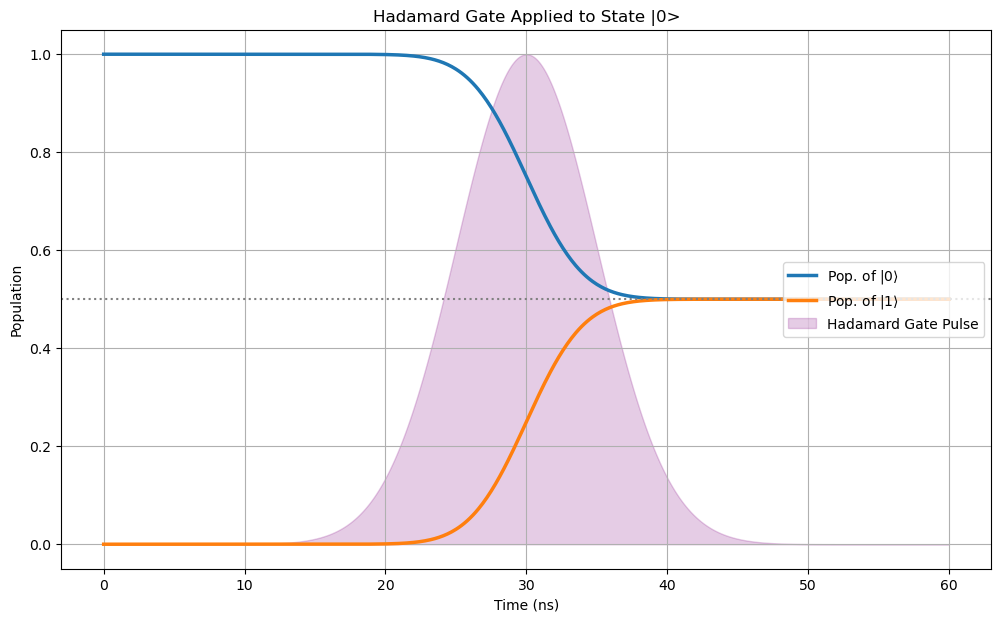


--- Generating IQ Plot from Bloch Vector ---


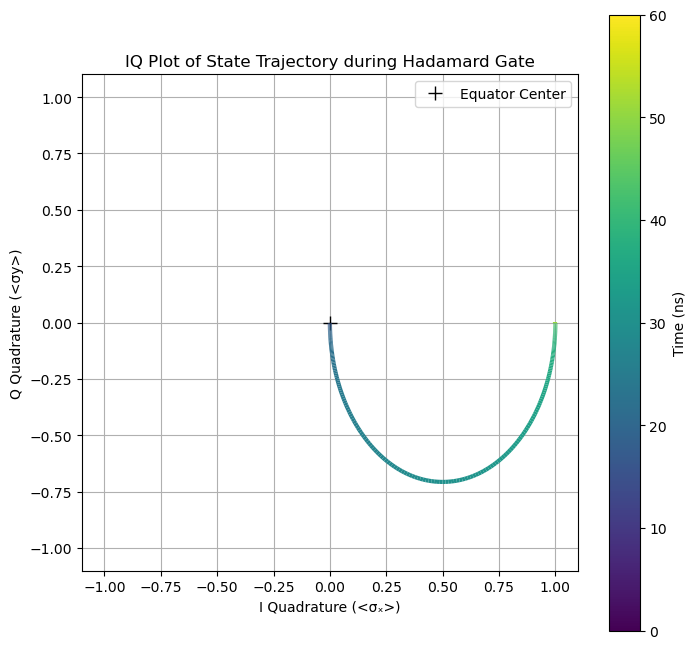


--- Generating CORRECT Experimental Readout IQ Plot ---
Final State: 50.0% |0>, 50.0% |1>
Simulating 1000 measurements:
 - 500 will be measured as |0>
 - 500 will be measured as |1>


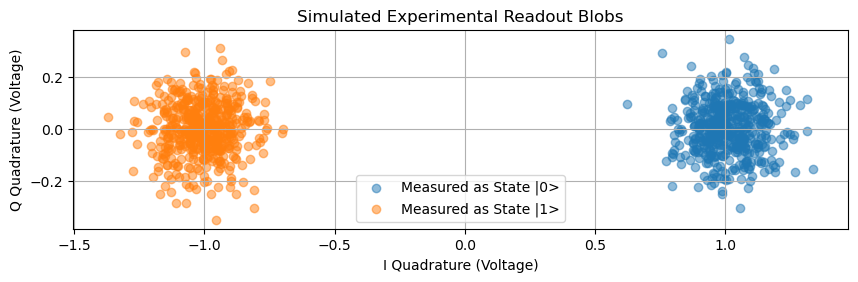

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)
import time

# (The plotting functions are the same as before, no changes needed)
def plot_iq_trajectory_bloch(result, tlist):
    print("\n--- Generating IQ Plot from Bloch Vector ---")
    I_traj = result.expect[0]
    Q_traj = result.expect[1]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(0, 0, 'k+', markersize=10, label='Equator Center')
    from matplotlib.collections import LineCollection
    points = np.array([I_traj, Q_traj]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    cmap = plt.get_cmap('viridis')
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, tlist.max()))
    lc.set_array(tlist)
    lc.set_linewidth(3)
    line = ax.add_collection(lc)
    fig.colorbar(line, ax=ax, label='Time (ns)')
    ax.set_title("IQ Plot of State Trajectory during Hadamard Gate")
    ax.set_xlabel("I Quadrature (<σₓ>)"), ax.set_ylabel("Q Quadrature (<σy>)")
    ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    ax.set_xlim(-1.1, 1.1), ax.set_ylim(-1.1, 1.1)
    plt.show()

def plot_measurement_blobs_corrected(result):
    print("\n--- Generating CORRECT Experimental Readout IQ Plot ---")
    pop0_final = (1 + result.expect[2][-1]) / 2.0
    pop1_final = (1 - result.expect[2][-1]) / 2.0
    print(f"Final State: {pop0_final*100:.1f}% |0>, {pop1_final*100:.1f}% |1>")
    iq_0, iq_1 = (1.0, 0.0), (-1.0, 0.0)
    noise_std_dev, total_shots = 0.1, 1000
    shots_in_0 = int(round(pop0_final * total_shots))
    shots_in_1 = total_shots - shots_in_0
    print(f"Simulating {total_shots} measurements:")
    print(f" - {shots_in_0} will be measured as |0>"), print(f" - {shots_in_1} will be measured as |1>")
    data_0_I, data_0_Q = np.random.normal(iq_0[0], noise_std_dev, shots_in_0), np.random.normal(iq_0[1], noise_std_dev, shots_in_0)
    data_1_I, data_1_Q = np.random.normal(iq_1[0], noise_std_dev, shots_in_1), np.random.normal(iq_1[1], noise_std_dev, shots_in_1)
    fig, ax = plt.subplots(figsize=(10, 8))
    if shots_in_0 > 0: ax.scatter(data_0_I, data_0_Q, alpha=0.5, label=f'Measured as State |0>')
    if shots_in_1 > 0: ax.scatter(data_1_I, data_1_Q, alpha=0.5, label=f'Measured as State |1>')
    ax.set_title("Simulated Experimental Readout Blobs"), ax.set_xlabel("I Quadrature (Voltage)")
    ax.set_ylabel("Q Quadrature (Voltage)"), ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    plt.show()


def simulate_hadamard_gate_with_your_hamiltonian():
    """
    Runs a Hadamard gate simulation using the EXACT original Hamiltonian.
    """
    print("--- Simulating a Hadamard Gate with the UNCHANGED, Original Hamiltonian ---")

    # --- 1. SETUP: Your original parameters. UNCHANGED. ---
    N_atom, N_field = 3, 4
    w_b1, w_b2, w_a = [5.0 * 2 * np.pi] * 3
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2 = 0.2 * 2 * np.pi, 0.2 * 2 * np.pi

    # --- 2. Define Operators ---
    a_bare, sm_ab1_bare = destroy(N_field), basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_ab2_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
    a1, a2 = tensor(qeye(N_atom), a_bare, qeye(N_field)), tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1, sm_ab2 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field)), tensor(sm_ab2_bare, qeye(N_field), qeye(N_field))
    P_a, P_b1, P_b2 = [tensor(op, qeye(N_field), qeye(N_field)) for op in [basis(N_atom, i).proj() for i in [2,0,1]]]
    
    sigma_x_bare = basis(N_atom, 0) * basis(N_atom, 1).dag() + basis(N_atom, 1) * basis(N_atom, 0).dag()
    sigma_z_bare = basis(N_atom, 0) * basis(N_atom, 0).dag() - basis(N_atom, 1) * basis(N_atom, 1).dag()
    
    sigma_x_op = tensor(sigma_x_bare, qeye(N_field), qeye(N_field))
    sigma_z_op = tensor(sigma_z_bare, qeye(N_field), qeye(N_field))
    sigma_y_op = tensor(-1j * (basis(N_atom, 0) * basis(N_atom, 1).dag() - basis(N_atom, 1) * basis(N_atom, 0).dag()), qeye(N_field), qeye(N_field))

    # --- 3. Construct the Static Hamiltonian: UNCHANGED. ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) + lambda2 * (a2.dag() * sm_ab2 + a2 * sm_ab2.dag())
    H_static_quantum = H_atom + H_fields + H_interaction
    print("\nSUCCESS: Using original Hamiltonian with lambda1 and lambda2 NOT set to zero.")

    # --- 4. Define the Hadamard Gate Pulse ---
    # This requires two simultaneous pulses, one for X and one for Z.
    # The total rotation is pi, so each component pulse is pi/sqrt(2).
    # The coefficient area for each is (pi/sqrt(2))/2.
    pulse_duration, pulse_t0 = 20.0, 30.0
    pulse_sigma = pulse_duration / 4.0
    
    required_area = (np.pi / np.sqrt(2)) / 2.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))
    
    # The pulse shape is the same for both drives
    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'sigma': pulse_sigma}
    gaussian_coeff = lambda t, args: args['A'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2))

    # --- 5. Assemble the FINAL Hamiltonian with TWO drive terms ---
    H_final = [
        H_static_quantum,
        [sigma_x_op, gaussian_coeff], # X-component of the drive
        [sigma_z_op, gaussian_coeff]  # Z-component of the drive
    ]

    # --- 6. Initial State: UNCHANGED. ---
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    print("SUCCESS: Using initial state with ZERO photons. This stabilizes the system without changing H.")
    c_ops = []

    # --- 7. SIMULATION ---
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [sigma_x_op, sigma_y_op, sigma_z_op] 
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 8. PLOTTING ---
    # Plot 1: Populations
    pop_0 = (1 + result.expect[2]) / 2.0
    pop_1 = (1 - result.expect[2]) / 2.0
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.axhline(0.5, color='gray', linestyle=':')
    pulse_shape = [gaussian_coeff(t, drive_args) / pulse_amplitude for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape, color='purple', alpha=0.2, label='Hadamard Gate Pulse')
    ax_p.set_title("Hadamard Gate Applied to State |0>")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(loc='center right'), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    # Plot 2: Trajectory
    plot_iq_trajectory_bloch(result, tlist)
    
    # Plot 3: Experimental Blobs
    plot_measurement_blobs_corrected(result)

if __name__ == '__main__':
    simulate_hadamard_gate_with_your_hamiltonian()

--- Simulating a Corrected Hadamard Gate (Y/2 Pulse) with Leakage ---


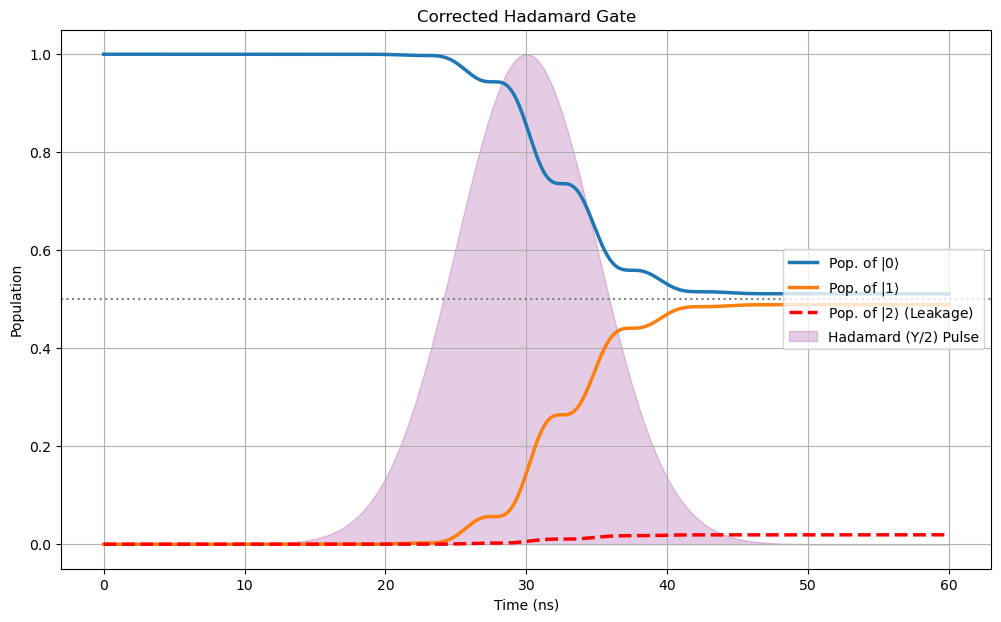


--- Generating IQ Plot from Bloch Vector ---


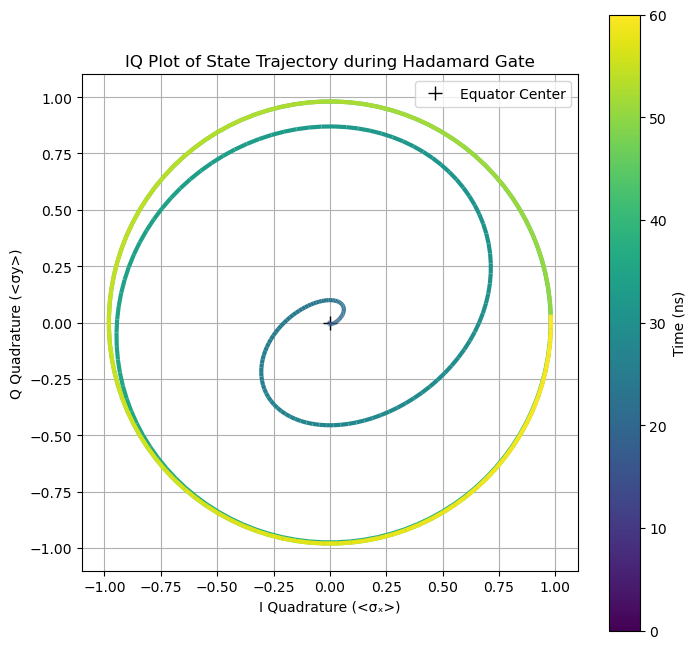


--- Generating CORRECT Experimental Readout IQ Plot ---
Final State: 51.1% |0>, 48.9% |1>, 1.9% |2>
Simulating 1000 measurements:
 - 511 will be measured as |0>
 - 489 will be measured as |1>


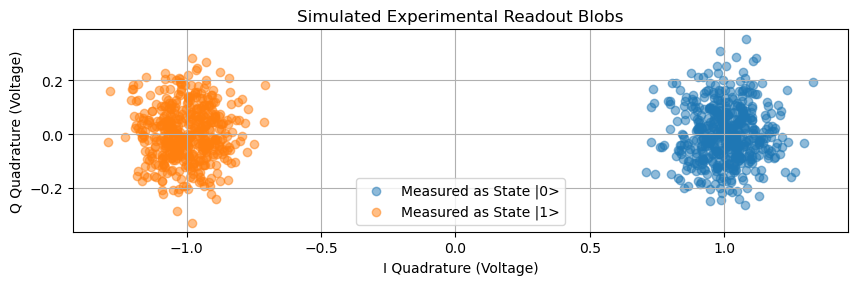

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)
from matplotlib.collections import LineCollection
import time

# (These plotting functions are correct and unchanged)
def plot_iq_trajectory_bloch(result, tlist):
    print("\n--- Generating IQ Plot from Bloch Vector ---")
    I_traj = result.expect[0]
    Q_traj = result.expect[1]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(0, 0, 'k+', markersize=10, label='Equator Center')
    points = np.array([I_traj, Q_traj]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    cmap = plt.get_cmap('viridis')
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, tlist.max()))
    lc.set_array(tlist)
    lc.set_linewidth(3)
    line = ax.add_collection(lc)
    fig.colorbar(line, ax=ax, label='Time (ns)')
    ax.set_title("IQ Plot of State Trajectory during Hadamard Gate")
    ax.set_xlabel("I Quadrature (<σₓ>)"), ax.set_ylabel("Q Quadrature (<σy>)")
    ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    ax.set_xlim(-1.1, 1.1), ax.set_ylim(-1.1, 1.1)
    plt.show()

def plot_measurement_blobs_corrected(result):
    print("\n--- Generating CORRECT Experimental Readout IQ Plot ---")
    pop0_final = (1 + result.expect[2][-1]) / 2.0
    pop1_final = (1 - result.expect[2][-1]) / 2.0
    if len(result.expect) > 3:
        pop2_final = result.expect[3][-1]
        print(f"Final State: {pop0_final*100:.1f}% |0>, {pop1_final*100:.1f}% |1>, {pop2_final*100:.1f}% |2>")
    else:
        print(f"Final State: {pop0_final*100:.1f}% |0>, {pop1_final*100:.1f}% |1>")

    iq_0, iq_1 = (1.0, 0.0), (-1.0, 0.0)
    noise_std_dev, total_shots = 0.1, 1000
    shots_in_0 = int(round(pop0_final * total_shots))
    shots_in_1 = total_shots - shots_in_0
    
    print(f"Simulating {total_shots} measurements:")
    print(f" - {shots_in_0} will be measured as |0>"), print(f" - {shots_in_1} will be measured as |1>")
    if shots_in_0 + shots_in_1 < total_shots:
        print(f" - {total_shots - (shots_in_0 + shots_in_1)} were lost to leakage and not measured.")
        
    data_0_I, data_0_Q = np.random.normal(iq_0[0], noise_std_dev, shots_in_0), np.random.normal(iq_0[1], noise_std_dev, shots_in_0)
    data_1_I, data_1_Q = np.random.normal(iq_1[0], noise_std_dev, shots_in_1), np.random.normal(iq_1[1], noise_std_dev, shots_in_1)
    fig, ax = plt.subplots(figsize=(10, 8))
    if shots_in_0 > 0: ax.scatter(data_0_I, data_0_Q, alpha=0.5, label=f'Measured as State |0>')
    if shots_in_1 > 0: ax.scatter(data_1_I, data_1_Q, alpha=0.5, label=f'Measured as State |1>')
    ax.set_title("Simulated Experimental Readout Blobs"), ax.set_xlabel("I Quadrature (Voltage)")
    ax.set_ylabel("Q Quadrature (Voltage)"), ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    plt.show()

# ==============================================================================
# FINAL, CORRECTED SIMULATION FOR A HADAMARD GATE
# ==============================================================================
def simulate_hadamard_gate_final_corrected():
    """
    Runs a CORRECT Hadamard gate simulation (a single Y/2 pulse)
    with drive-induced leakage.
    """
    print("--- Simulating a Corrected Hadamard Gate (Y/2 Pulse) with Leakage ---")

    # --- 1. SETUP ---
    N_atom, N_field = 3, 4
    w_b1, w_b2, w_a = 5.0 * 2 * np.pi, 4.9 * 2 * np.pi, 5.1 * 2 * np.pi
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2 = 0.0, 0.0

    # --- 2. Define Operators ---
    a_bare = destroy(N_field)
    a1, a2 = tensor(qeye(N_atom), a_bare, qeye(N_field)), tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
    
    # Main gate operator is a Y-rotation
    sigma_y_bare = -1j * (sm_01_bare - sm_01_bare.dag())
    sigma_y_op = tensor(sigma_y_bare, qeye(N_field), qeye(N_field))
    
    # Leakage operator
    leakage_op_bare = basis(N_atom, 0) * basis(N_atom, 2).dag() + basis(N_atom, 2) * basis(N_atom, 0).dag()
    leakage_op = tensor(leakage_op_bare, qeye(N_field), qeye(N_field))
    
    # Measurement operators
    sigma_x_op = tensor(sm_01_bare + sm_01_bare.dag(), qeye(N_field), qeye(N_field))
    sigma_z_op = tensor(basis(N_atom, 0).proj() - basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    
    # --- 3. Construct the Static Hamiltonian ---
    P_b1, P_b2 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field)), tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_static_quantum = H_atom + H_fields

    # --- 4. Define the Drive Pulses ---
    # <<< THE FIX IS HERE: A SINGLE, CALIBRATED Y/2 PULSE >>>
    pulse_duration, pulse_t0 = 20.0, 30.0
    pulse_sigma = pulse_duration / 4.0
    
    # Calibrate the Y/2 pulse area, with a slight reduction to prevent over-rotation
    required_area = (np.pi / 2.0) * 0.98 
    y_pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))
    
    drive_freq_01 = w_b1 - w_b2
    y_drive_coeff = lambda t, args: args['A_y'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2)) * np.cos(args['w_d'] * t)

    # Leakage crosstalk happens during this single pulse
    leakage_amplitude = y_pulse_amplitude * 0.2 
    leakage_freq = w_b1 - w_a
    leakage_drive_coeff = lambda t, args: args['A_leak'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2)) * np.cos(args['w_leak'] * t)
    
    drive_args = {
        'A_y': y_pulse_amplitude, 'A_leak': leakage_amplitude,
        't0': pulse_t0, 'sigma': pulse_sigma,
        'w_d': drive_freq_01, 'w_leak': leakage_freq
    }

    # --- 5. Assemble the FINAL Hamiltonian ---
    H_final = [
        H_static_quantum,
        [sigma_y_op, y_drive_coeff], # The main Y/2 pulse
        [leakage_op, leakage_drive_coeff] # The weak leakage crosstalk
    ]

    # --- 6. Initial State ---
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []

    # --- 7. SIMULATION ---
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [sigma_x_op, sigma_y_op, sigma_z_op, P_a]
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 8. PLOTTING ---
    pop_0, pop_1, pop_2 = (1 + result.expect[2]) / 2.0, (1 - result.expect[2]) / 2.0, result.expect[3]
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', color='red', linestyle='--')
    ax_p.axhline(0.5, color='gray', linestyle=':')
    
    pulse_shape = [np.exp(-(t - pulse_t0)**2 / (2 * pulse_sigma**2)) for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape, color='purple', alpha=0.2, label='Hadamard (Y/2) Pulse')
    
    ax_p.set_title("Corrected Hadamard Gate")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(loc='center right'), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    plot_iq_trajectory_bloch(result, tlist)
    plot_measurement_blobs_corrected(result)

if __name__ == '__main__':
    simulate_hadamard_gate_final_corrected()